# GRA: signum figs (mnist, cifar, imgnet)

project = ```GRA```, host = ```any```, device = ```any```


In [1]:
# HIDE CODE


project_name = '_GRA'

import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from gra.utils.plotting import *
from experiments.vision.test import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
# HIDE CODE


from experiments.figures.fighelper import (
    generate_optimizer_cmap,
    parse_optimizer_key,
    get_varying_params,
)


def get_cmap(keys, family_colors=None, verbose=False):
    family_colors = family_colors or {
        'Rel. Signum': 'bluish',
        'Signum': 'reddish',
        'AdamW': 'grayish',
    }
    # Generate colormap
    cmap, info = generate_optimizer_cmap(
        keys, family_colors=family_colors)

    if verbose:
        print("Family Info:")
        for family, finfo in info.items():
            print(f"  {family}: sorted by {finfo['sort_params']}, {finfo['n_configs']} configs")

#     print("\nGenerated Colors (sample):")
#     for i, (key, color) in enumerate(cmap.items()):
#         if i < 5 or i >= len(cmap) - 3:
#             print(f"  {key[:55]:55s} -> {matplotlib.colors.rgb2hex(color)}")
#         elif i == 5:
#             print("  ...")

        # Visualize as color swatches per family
        fig, axes = plt.subplots(1, 3, figsize=(16, 8))

        for ax, family in zip(axes, ['AdamW', 'Rel. Signum', 'Signum']):
            # Get all keys for this family in sorted order
            family_keys = [k for k in keys if k.startswith(family + ' ')]

            # Sort by the hierarchical order (same as cmap generation)
            parsed_configs = [(k, parse_optimizer_key(k)[1]) for k in family_keys]
            varying = get_varying_params([p for _, p in parsed_configs])


            def sort_key(item):
                _, params = item
                return tuple(params.get(p, 0) for p in varying)


            sorted_keys = [k for k, _ in sorted(parsed_configs, key=sort_key)]

            colors = [cmap[k] for k in sorted_keys]

            # Create color swatch visualization
            n = len(sorted_keys)
            for i, (key, color) in enumerate(zip(sorted_keys, colors)):
                ax.barh(i, 1, color=color, height=0.9)

            ax.set_yticks(range(n))
            # Show abbreviated labels (just the varying params)
            labels = []
            for k in sorted_keys:
                _, params = parse_optimizer_key(k)
                label = ', '.join(f'{p}={params[p]}' for p in varying if p in params)
                labels.append(label)
            ax.set_yticklabels(labels, fontsize=7)
            ax.set_xlim(0, 1)
            ax.set_xticks([])
            ax.set_title(f'{family}\n(sorted by: {", ".join(varying)})', fontsize=14)
            ax.invert_yaxis()

        plt.tight_layout()
        plt.show()
    
    return cmap


def _sort_optim_family(results, optimizer_names):
    def sort_key(k):
        for i, name in enumerate(optimizer_names):
            if k.startswith(name):
                return (i, k)
        return (len(optimizer_names), k)

    return {k: results[k] for k in sorted(results, key=sort_key)}


def _prep_data(results_dict, n_top_fits=3, n_last_timepoints=10):
    # model_accuracies (avg of last n timepoints)
    model_accuracies = collections.defaultdict(dict)

    for k, d in results_dict.items():
        name = k.split('(')[0].strip()
        acc = d['test_acc'].mean(0)[-n_last_timepoints:].mean()
        model_accuracies[name][k] = acc

    model_accuracies = {
        k: dict(sorted(d.items(), key=lambda t: t[1]))
        for k, d in model_accuracies.items()
    }

    # select best n fits per optim family
    best_n_models = {
        k: dict(list(d.items())[-n_top_fits:])
        for k, d in model_accuracies.items()
    }
    
    # best n fits (keys only)
    best_n_models_strings = [
        x for d in best_n_models.values()
        for x in list(d)
    ]
    
    return model_accuracies, best_n_models, best_n_models_strings


def _plot(
    results, key='test_acc',
    intvl=slice(-21, None),
    colors=None, smooth=None, ylim=None,
    figsize=(9, 4), dpi=100, ):

    fig, ax = create_figure(1, 1, figsize=figsize, dpi=dpi)

    for i, (k, d) in enumerate(results.items()):
        if colors is not None:
            color = colors[k]
        else:
            color = f"C{i}"

        mu = d[key].mean(0)
        sd = d[key].std(0)

        if smooth is not None:
            mu = smooth_savgol(mu, smooth, polyorder=3)
            sd = smooth_savgol(sd, smooth, polyorder=3)
            
        xs = np.arange(1, len(mu) + 1)

        xs = xs[intvl]
        mu = mu[intvl]
        sd = sd[intvl]

        ax.plot(xs, mu + sd, color=color, ls='--', lw=0.8, alpha=1.0)
        ax.plot(xs, mu, color=color, label=k, marker='.')
        ax.plot(xs, mu - sd, color=color, ls='--', lw=0.8, alpha=1.0)
        plt.fill_between(xs, mu - sd, mu + sd, color=color, alpha=0.1)

    if ylim is not None:
        ax.set(ylim=ylim)

    ax.legend()
    move_legend(ax, (1.01, 1.01))
    plt.show()

    return

In [3]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: mach

## Results: MNIST

In [39]:
results_mnist = 'MNIST_results_jan02.npy'
results_mnist = pjoin(tmp_dir, results_mnist)
results_mnist = np.load(results_mnist, allow_pickle=True).item()

In [40]:
optimizer_names = ['Rel. Signum', 'Signum', 'AdamW']
results_mnist = _sort_optim_family(results_mnist, optimizer_names)

cmap = get_cmap(list(results_mnist))

In [41]:
model_accuracies, best_n_models, best_n_models_strings = _prep_data(
    results_dict=results_mnist)

In [42]:
print(best_n_models)

{
    'Rel. Signum': {
        'Rel. Signum (lr=0.0005,beta=0.95,wd=0.1,mass=5)': 98.57666666666667,
        'Rel. Signum (lr=0.0001,beta=0.8,wd=0.1,mass=1)': 98.58200000000001,
        'Rel. Signum (lr=0.0001,beta=0.95,wd=0.1,mass=5)': 98.62833333333333
    },
    'Signum': {
        'Signum (lr=0.0001,beta=0.95,wd=0.1,dampening=0.1)': 98.35166666666666,
        'Signum (lr=0.0001,beta=0.95,wd=0.1,dampening=0.5)': 98.38166666666667,
        'Signum (lr=0.0001,beta=0.95,wd=0.1,dampening=0.0)': 98.389
    },
    'AdamW': {
        'AdamW (lr=0.0005,beta=0.8,wd=0.1)': 98.43966666666668,
        'AdamW (lr=0.001,beta=0.95,wd=0.1)': 98.471,
        'AdamW (lr=0.0005,beta=0.95,wd=0.1)': 98.54133333333334
    }
}

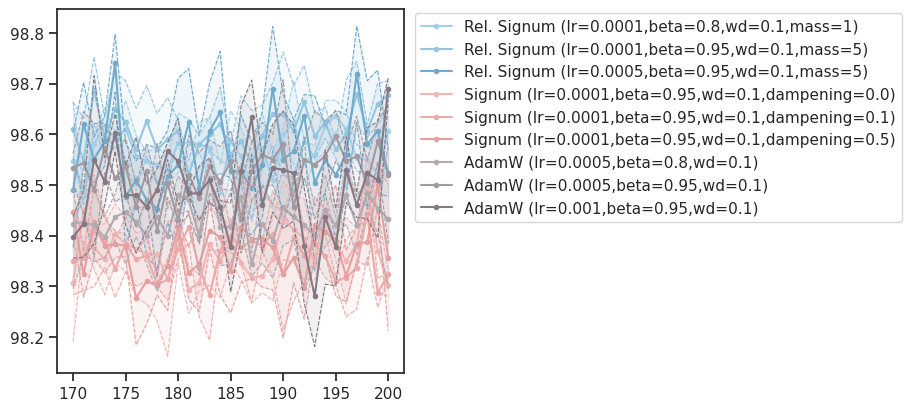

In [43]:
selected_results = {
    k: v for k, v in results_mnist.items()
    if k in best_n_models_strings
}

_plot(selected_results, intvl=slice(-31, None), colors=cmap)

In [48]:
selected_keys = sorted([
    k for k in results_mnist if
    'lr=0.001,beta=0.95' in k
], key=alphanum_sort_key)

selected_results = {k: results_mnist[k] for k in selected_keys}

selected_cmap = get_cmap(selected_results, family_colors={
    'Rel. Signum': 'bluish', 'Signum': 'red', 'AdamW': 'green'})
selected_cmap['AdamW (lr=0.001,beta=0.95,wd=0.1)'] = 'C2'

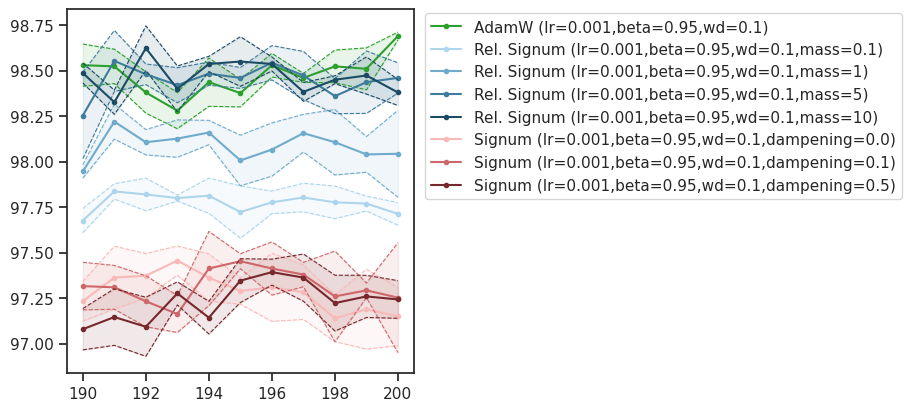

In [49]:
_plot(selected_results, intvl=slice(-11, None), colors=selected_cmap)

## Results: CIFAR10

In [10]:
results_cifar = 'CIFAR10_results_jan03.npy'
results_cifar = pjoin(tmp_dir, results_cifar)
results_cifar = np.load(results_cifar, allow_pickle=True).item()

In [11]:
optimizer_names = ['Rel. Signum', 'Signum', 'AdamW']
results_cifar = _sort_optim_family(results_cifar, optimizer_names)

cmap = get_cmap(list(results_cifar))

In [12]:
model_accuracies, best_n_models, best_n_models_strings = _prep_data(
    results_dict=results_cifar)

In [13]:
print(best_n_models)

{
    'Rel. Signum': {
        'Rel. Signum (lr=0.0005,beta=0.95,wd=0.1,mass=10)': 87.84566666666667,
        'Rel. Signum (lr=0.0001,beta=0.95,wd=0.1,mass=5)': 87.94333333333334,
        'Rel. Signum (lr=0.0001,beta=0.95,wd=0.1,mass=10)': 88.081
    },
    'Signum': {
        'Signum (lr=0.0001,beta=0.95,wd=0.1,dampening=0.1)': 86.83933333333333,
        'Signum (lr=0.0001,beta=0.95,wd=0.1,dampening=0.5)': 86.90966666666667,
        'Signum (lr=0.0001,beta=0.95,wd=0.1,dampening=0.0)': 86.94200000000001
    },
    'AdamW': {
        'AdamW (lr=0.0005,beta=0.8,wd=0.1)': 84.95433333333332,
        'AdamW (lr=0.001,beta=0.95,wd=0.1)': 85.119,
        'AdamW (lr=0.0005,beta=0.95,wd=0.1)': 85.35999999999999
    }
}

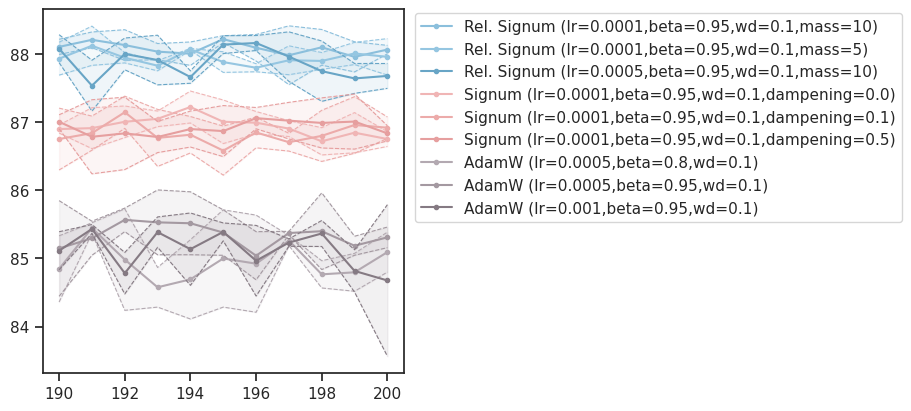

In [14]:
selected_results = {
    k: v for k, v in results_cifar.items()
    if k in best_n_models_strings
}

_plot(selected_results, intvl=slice(-11, None), colors=cmap)

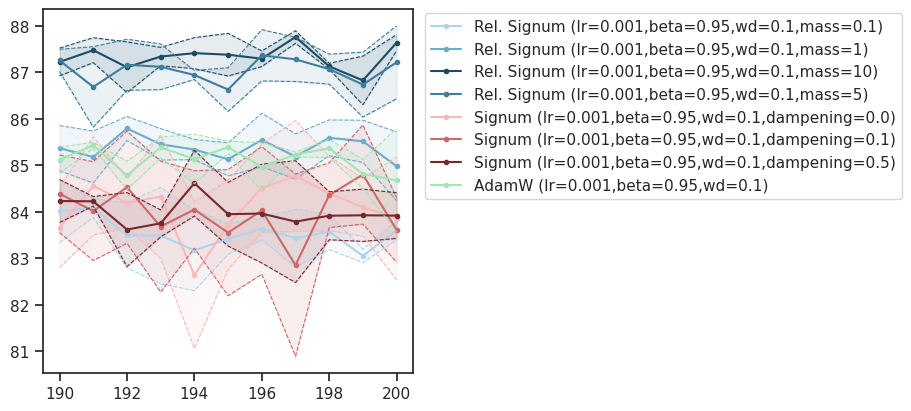

In [15]:
selected_results = {
    k: v for k, v in results_cifar.items()
    if 'lr=0.001,beta=0.95' in k
}
selected_cmap = get_cmap(selected_results, family_colors={
    'Rel. Signum': 'bluish', 'Signum': 'red', 'AdamW': 'green'})

_plot(selected_results, intvl=slice(-11, None), colors=selected_cmap)

## Results: ImageNet32

**TODO:** awaiting ImgNet fits wiht seeds. That should clarify better

In [16]:
results_imgnet = 'ImageNet32_results_jan06.npy'
results_imgnet = pjoin(tmp_dir, results_imgnet)
results_imgnet = np.load(results_imgnet, allow_pickle=True).item()

In [17]:
optimizer_names = ['Rel. Signum', 'Signum', 'AdamW']
results_imgnet = _sort_optim_family(results_imgnet, optimizer_names)

In [18]:
cmap = get_cmap(list(results_imgnet) + list(results_cifar))

In [19]:
model_accuracies, best_n_models, best_n_models_strings = _prep_data(
    results_dict=results_imgnet)

In [20]:
print(best_n_models)

{
    'Rel. Signum': {
        'Rel. Signum (lr=0.001,beta=0.95,wd=0.1,mass=0.5)': 36.13080000000001,
        'Rel. Signum (lr=0.001,beta=0.95,wd=0.1,mass=0.1)': 36.6742,
        'Rel. Signum (lr=0.001,beta=0.95,wd=0.1,mass=0.01)': 37.1022
    },
    'Signum': {
        'Signum (lr=0.005,beta=0.95,wd=0.1,dampening=0.0)': 3.4453999999999994,
        'Signum (lr=0.0005,beta=0.95,wd=0.1,dampening=0.0)': 32.262,
        'Signum (lr=0.001,beta=0.95,wd=0.1,dampening=0.0)': 37.230000000000004
    },
    'AdamW': {
        'AdamW (lr=0.005,beta=0.95,wd=0.1)': 28.692,
        'AdamW (lr=0.0005,beta=0.95,wd=0.1)': 31.3728,
        'AdamW (lr=0.001,beta=0.95,wd=0.1)': 35.544
    }
}

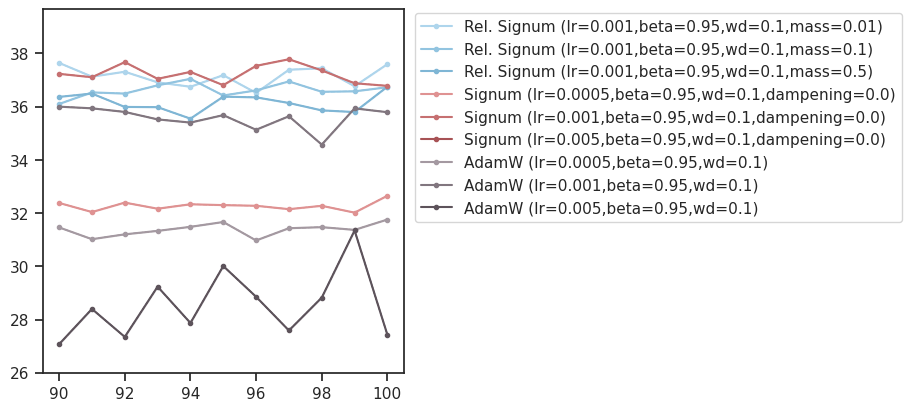

In [21]:
selected_results = {
    k: v for k, v in results_imgnet.items()
    if k in best_n_models_strings
}

_plot(selected_results, intvl=slice(-11, None), ylim=(26, None), colors=cmap)

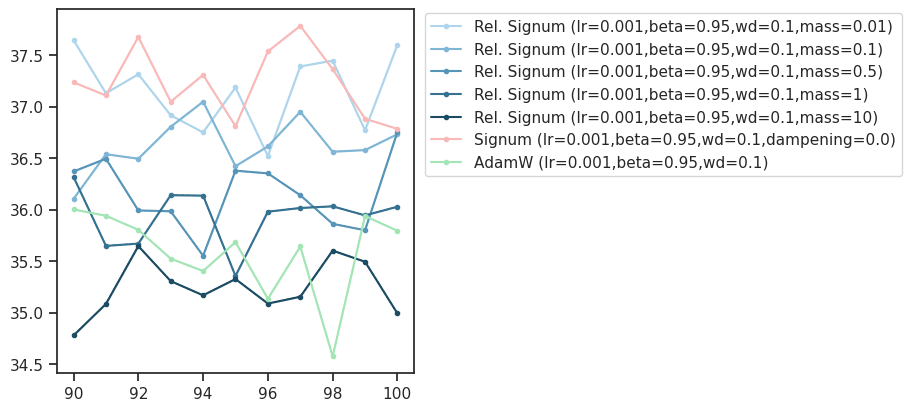

In [22]:
selected_results = {
    k: v for k, v in results_imgnet.items()
    if 'lr=0.001,beta=0.95' in k
}
selected_cmap = get_cmap(selected_results, family_colors={
    'Rel. Signum': 'bluish', 'Signum': 'red', 'AdamW': 'green'})

_plot(selected_results, intvl=slice(-11, None), colors=selected_cmap)

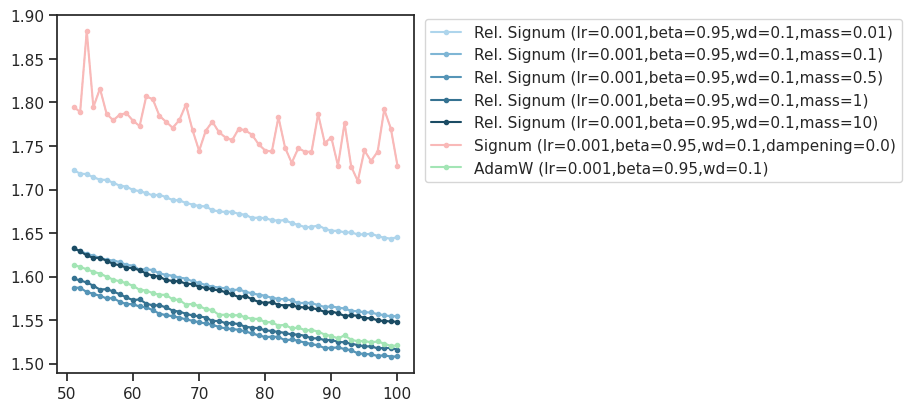

In [23]:
selected_results = {
    k: v for k, v in results_imgnet.items()
    if 'lr=0.001,beta=0.95' in k
}
selected_cmap = get_cmap(selected_results, family_colors={
    'Rel. Signum': 'bluish', 'Signum': 'red', 'AdamW': 'green'})

_plot(selected_results, key='train_loss', intvl=slice(-50, None), colors=selected_cmap)